### ENSIMAG – Grenoble INP – UGA - Academic year 2025-2026
# Introduction to Statistical Learning and Applications ([website](https://github.com/ISLA-Grenoble/2026-main))

- Pedro L. C. Rodrigues -- `pedro.rodrigues@inria.fr`

- Isabella Costa Maia -- `isabella.costa-maia@grenoble-inp.fr`

***

### ⚠️ General guidelines for TPs

Each team shall upload its report on [Teide](https://teide.ensimag.fr/) before the deadline indicated at the course website. Please
**include the name of all members** of the team on top of your report.
The report should contain graphical representations and explanatory text. For each graph, axis names should be provided as well
as a legend when it is appropriate. Figures should be explained by a few sentences in the text. Answer to
the questions in order and refer to the question number in your report. Computations and
graphics have to be performed in `python`. The report should be written as a jupyter notebook. This is a file format that allows users to format documents containing text written in markdown and `python` instructions. You should include all of the `python` instructions that you have used in the document so that it may be possible to replicate your results.

***

# 🖥️ TP1: Analysis of prostate cancer data

A medical study done on patients with prostate cancer aims to analyze the correlation between the prostate tumor volume and a set of clinical and morphometric variables. These variables include prostate specific antigens, a biomarker for prostate cancer, and a number of clinical measures (age, prostate weight, etc). The goal of this lab is to build a regression model to predict the severity of cancer, expressed by logarithm of the tumor volume -- `lcavol` variable -- from the following predictors:
- `lpsa`: log of a prostate specific antigen
- `lweight`: log of prostate weight
- `age`: age of the patient
- `lbph`: log of benign prostatic hyperplasia amount
- `svi`: seminal vesicle invasion
- `lcp`: log of capsular penetration
- `gleason`: Gleason score (score on a cancer prognosis test)
- `pgg45`: percent of Gleason scores 4 or 5

The file `prostate.data`, available [here](https://github.com/ISLA-Grenoble/2025-main/blob/main/TP/TP1/prostate.data), contains measures of the logarithm of the tumor
volume and of the 8 predictors for 97 patients. This file also contains an additional variable, called `train`, which will
not be used and has to be removed.

## ▶️ Exercise 1: Preliminary analysis of the data (1 points)

**(a)** Download the file `prostate.data` and store it in your current folder. Read the dataset in using `pandas` as per
```
import pandas as pd
df = pd.read_csv("prostate.data", sep="\t")
```
check how to use function `df.drop` to remove the first and last columns of `df` containing useless tags.

In [1]:
import pandas as pd
df = pd.read_csv("prostate.data", sep="\t")
df = df.drop(columns=df.columns[[0, -1]])

**(b)** The function defined below generates scatterplots (clouds of points) between all pairs of variables, allowing us to visually analyse the correlations between all variables in the dataframe. Explain what each line of function `pairplot` does and how it affects the final plot. You can use command `help` in the `python` shell to get the documentation of each function.

``` 
# import the main plotting library for python
import matplotlib.pyplot as plt

# make a pairplot from scratch
def pairplot(df, figsize=None):
    # takes a dataframe and the size of the figure (optional) as parameters
    if figsize is None:
        figsize = (7.10, 6.70)
    n_vars = df.shape[1] #number of columns
    fig, ax = plt.subplots(figsize=figsize, ncols=n_vars, nrows=n_vars)
    #Creates a grid of n_vars × n_vars subplots. fig is the overall figure, ax is a 2D array of individual subplot axes.
    plt.subplots_adjust(
        wspace=0.10, hspace=0.10, left=0.05, right=0.95, bottom=0.05, top=0.95) 
    #spaces and margins 
    for i in range(n_vars):
        for j in range(n_vars):
            axij = ax[i][j]
            i_name = df.columns[i]
            j_name = df.columns[j]
            axij.set_xticks([])
            axij.set_yticks([])
            axij.margins(0.1)
            if i != j:
                axij.scatter(df[i_name], df[j_name], s=10)
            else:
                axij.text(0.5, 0.5, i_name, fontsize=10,
                              horizontalalignment='center',
                              verticalalignment='center',
                              transform = axij.transAxes)        
    return fig, ax

fig, ax = pairplot(df)
plt.show()
```

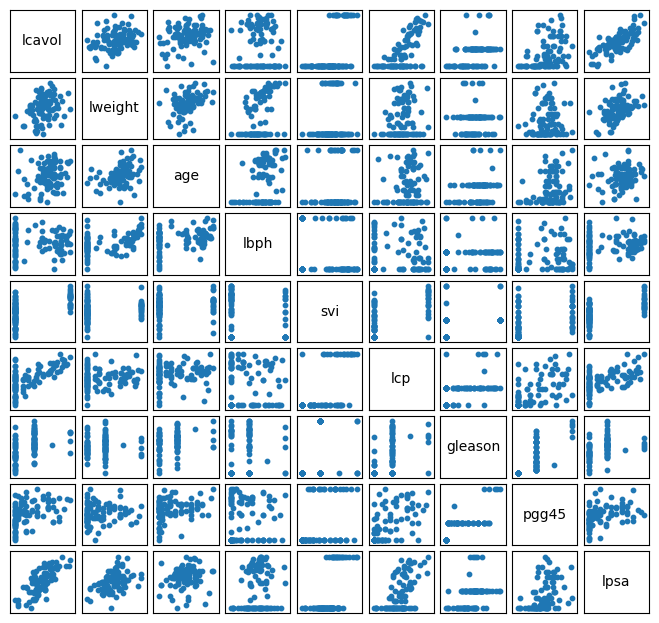

In [2]:
# import the main plotting library for python
import matplotlib.pyplot as plt

# make a pairplot from scratch
def pairplot(df, figsize=None):
    # takes a dataframe and the size of the figure (optional) as parameters
    if figsize is None:
        figsize = (7.10, 6.70)
    n_vars = df.shape[1] #number of columns
    fig, ax = plt.subplots(figsize=figsize, ncols=n_vars, nrows=n_vars)
    #Creates a grid of n_vars × n_vars subplots. fig is the overall figure, ax is a 2D array of individual subplot axes.
    plt.subplots_adjust(
        wspace=0.10, hspace=0.10, left=0.05, right=0.95, bottom=0.05, top=0.95) 
    #spaces and margins 
    #9x9 subplots for each variable in the dataset, 97 points for each patient in each subplot
    for i in range(n_vars):
        for j in range(n_vars):
            axij = ax[i][j]
            i_name = df.columns[i]
            j_name = df.columns[j]
            axij.set_xticks([])
            axij.set_yticks([])
            axij.margins(0.1)
            if i != j:
                axij.scatter(df[i_name], df[j_name], s=10)
            else:
                axij.text(0.5, 0.5, i_name, fontsize=10,
                              horizontalalignment='center',
                              verticalalignment='center',
                              transform = axij.transAxes)        
    return fig, ax

fig, ax = pairplot(df)
plt.show()

**(c)** Based on the generated figure, identify which variables seem the most correlated to `lcavol`. Also, infer the datatype for each of the predictors.

the variables which are the most correlated to lcavol seem to be lcp and lpsa. lcavol, lweight, age, lbph, lcp, pgg45, and lpsa are continuous, whereas svi and gleason are qualitative (svi has 2 possible values, gleason has 4)

**(d)** Recall the formula of correlation between two vectors and implement it with `numpy`. Explain the difference of your result when compared to `df.corr()`. Change the function `pairplot`to show the correlation coefficient on the upper triangle of the subplots. (Bonus) Use locally weighted scatterplot smoothing (LOWESS) to see the trends between pairs of features with `statsmodels.nonparametric.smoothers_lowess`.

$$r = \frac{\sum_{i=1}^{n}(u_i - \bar{u})(v_i - \bar{v})}{\sqrt{\sum_{i=1}^{n}(u_i - \bar{u})^2 \cdot \sum_{i=1}^{n}(v_i - \bar{v})^2}}$$

df.corr() provides a 9x9 grid of correlations of all variables with eachother whereas what i implemented only calculates the correlation between 2 given vectors.

In [3]:
import numpy as np
def correlation(u, v):
    num = 0
    denom_u = 0
    denom_v = 0
    for i in range( len(u)):
        num+=(u[i]-u.mean())*(v[i]-v.mean())
        denom_u+=(u[i]-u.mean())**2
        denom_v+=(v[i]-v.mean())**2
    return num/(np.sqrt(denom_u*denom_v))

r = correlation(df['lcavol'].values, df['lpsa'].values)
print(r)
print(df.corr())

0.7344603262136732
           lcavol   lweight       age      lbph       svi       lcp   gleason  \
lcavol   1.000000  0.280521  0.225000  0.027350  0.538845  0.675310  0.432417   
lweight  0.280521  1.000000  0.347969  0.442264  0.155385  0.164537  0.056882   
age      0.225000  0.347969  1.000000  0.350186  0.117658  0.127668  0.268892   
lbph     0.027350  0.442264  0.350186  1.000000 -0.085843 -0.006999  0.077820   
svi      0.538845  0.155385  0.117658 -0.085843  1.000000  0.673111  0.320412   
lcp      0.675310  0.164537  0.127668 -0.006999  0.673111  1.000000  0.514830   
gleason  0.432417  0.056882  0.268892  0.077820  0.320412  0.514830  1.000000   
pgg45    0.433652  0.107354  0.276112  0.078460  0.457648  0.631528  0.751905   
lpsa     0.734460  0.433319  0.169593  0.179809  0.566218  0.548813  0.368987   

            pgg45      lpsa  
lcavol   0.433652  0.734460  
lweight  0.107354  0.433319  
age      0.276112  0.169593  
lbph     0.078460  0.179809  
svi      0.457648  0

## ▶️ Exercise 2: Linear regression (7 points)

In this exercise, we will perform a multiple linear regression to build a predictive model for the `lcavol` variable. The variables `gleason` and `svi` should be considered as qualitative variables. You can declare them as such with

```
df['svi'] = df['svi'].astype("category")
df['gleason'] = df['gleason'].astype("category")
```

**(a)** Provide the mathematical equation of the regression model (note that you can use LaTeX to write equations) and define the diﬀerent parameters. 

In [4]:
df['svi'] = df['svi'].astype("category")
df['gleason'] = df['gleason'].astype("category")

$$\text{lcavol}_i = \beta_0 + \beta_1 \cdot \text{lpsa}_i + \beta_2 \cdot \text{lweight}_i + 
\beta_3 \cdot \text{age}_i + \beta_4 \cdot \text{lbph}_i + \beta_5 \cdot \text{svi}_i + 
\beta_6 \cdot \text{lcp}_i + \beta_7 \cdot \text{gleason}_i + \beta_8 \cdot \text{pgg45}_i + \varepsilon_i$$

**(b)** Before doing the linear regression of this TP, you will first have to handle the one-hot encoding of the categorical features of the dataframe. One way of doing this is as follows:

```
# encode the categorical features with dummy variables
df_enc = pd.get_dummies(df, dtype=np.float64)
# to drop one dummy column for each predictor
df_enc = df_enc.drop(columns=['svi_0', 'gleason_6'])
# add a column of ones to the dataframe
df_enc['intercept'] = 1
# extract the dataframe for predictors
X = df_enc.drop(columns=['lcavol'])
# get the observed values to predict
y = df['lcavol']
```

- Why did we fix a `dtype` in `pd.get_dummies`?
- Why did we drop two columns after the encoding?
- Why did we add a column of ones to the dataframe?

pd.getdummies finds any qualitative (categorical) variables and replaces each one with binary columns, the new columns are boolean by default but we need floats for regression, which is why we need to fix the dtype as float.
The two columns are dropped because they're redundant. for svi for example, it only has 2 possible values, so if svi_1=0, we can conclude svi_0=1 without the need to keep the column, same logic applies to gleason.
The column of ones is so the baseline value for lcavol isnt 0. it meant the value of $\beta_0$ gets multiplied by 1 in the equation of regression above.

**(c)** We will use the [`statsmodels`](https://www.statsmodels.org/) package to estimate the coefficients of the multiple linear regression as per:

```
# import required package
import statsmodels.api as sm
# this line does not fit the regression model per se but only builds it
model = sm.OLS(y, X)
# now we actually fit the model, e.g. calculate all of regression parameters
results = model.fit()
```

Use command `results.sumary()` to get the statistical summary of the estimated coefficients. 

- Explain to what correspond the regression coeﬃcients for the lines related to `svi` and `gleason`. 

- What would have happened in the regression if we did not do the one-hot encoding from above?

- Comment the overall results of the regression as well.

In [5]:
# encode the categorical features with dummy variables
df_enc = pd.get_dummies(df, dtype=np.float64)
# to drop one dummy column for each predictor
df_enc = df_enc.drop(columns=['svi_0', 'gleason_6'])
# add a column of ones to the dataframe
df_enc['intercept'] = 1
# extract the dataframe for predictors
X = df_enc.drop(columns=['lcavol'])
# get the observed values to predict
y = df['lcavol']
import statsmodels.api as sm
model = sm.OLS(y, X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                 lcavol   R-squared:                       0.686
Model:                            OLS   Adj. R-squared:                  0.650
Method:                 Least Squares   F-statistic:                     18.83
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           9.05e-18
Time:                        17:54:39   Log-Likelihood:                -96.825
No. Observations:                  97   AIC:                             215.7
Df Residuals:                      86   BIC:                             244.0
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
lweight       -0.0112      0.211     -0.053      0.9

Compared to patients whose svi=0, patients with svi have on average 0.2204 units lower lcavol. However the p-value is above 0.05 so its not significant. For gleason, it's the same but using gleason_6 as a reference.
If we hadn't done one-hot encoding, the model would have treated gleason scores (6, 7, 8, 9) as real numbers, wrongly assuming that the difference between each score is equal and consistent, when in reality they are just category labels with no guaranteed mathematical relationship.
lcp and lpsa are the strongest predictors for lcavol. The overall model explains 68.6% of variation in tumor volume, which is reasonably good and is globally significant.

**(d)** Use `results.conf_int` to get confidence intervals of level 95% for all the coeﬃcients of the predictors. Comment the results.

In [27]:
print(results.conf_int(alpha=0.05))

                  0         1
lweight   -0.431600  0.409107
age        0.002436  0.047129
lbph      -0.219914  0.011515
lcp        0.233639  0.571880
pgg45     -0.018469 -0.000419
lpsa       0.370474  0.728673
svi_1     -0.730029  0.289190
gleason_7 -0.116263  0.739616
gleason_8 -2.219087  0.797911
gleason_9 -0.179004  1.759273
intercept -3.145013  0.331705


The intervals that are entirely positive (lcp, lpsa, age, pgg45) are significant, the rest are not, they could have zero effect on lcavol.

**(e)** What can you say about the eﬀects of the `lpsa` variable? Relate your answer to the $p$-value of a hypothesis test and a confidence interval. You can use `results.pvalues`.

In [28]:
print(results.pvalues['lpsa'])

2.9392406466908175e-08


In [ ]:
the confidence interval shows lpsa is significant, and the p-value being very low further proves lpsa has great effect on lcavol.

**(f)** Implement yourself a function that calculates the values of the parameters and their corresponding $p$-values. Bonus: explain why `numpy.linalg.inv` is not necessarily the best choice for estimating the parameters as compared to `numpy.linalg.solve`.

In [6]:
import numpy as np
from scipy import stats

def my_regression(X, y):
    X_mat = X.values  
    y_vec = y.values  
    n, p = X_mat.shape  # n = number of patients, p = number of predictors
    beta_hat = np.linalg.solve(X_mat.T @ X_mat, X_mat.T @ y_vec)
    
    residuals = y_vec - X_mat @ beta_hat

    sigma2 = np.sum(residuals**2) / (n - p)
    
    cov_beta = sigma2 * np.linalg.inv(X_mat.T @ X_mat)
    
    se = np.sqrt(np.diag(cov_beta))
    
    t_stats = beta_hat / se
    
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=n-p))
    
    print(f"{'Predictor':<15} {'coef':>10} {'p-value':>10}")
    print("-" * 40)
    for i, name in enumerate(X.columns):
        print(f"{name:<15} {beta_hat[i]:>10.4f} {p_values[i]:>10.4f}")

my_regression(X, y)

Predictor             coef    p-value
----------------------------------------
lweight            -0.0112     0.9577
age                 0.0248     0.0301
lbph               -0.1042     0.0770
lcp                 0.4028     0.0000
pgg45              -0.0094     0.0405
lpsa                0.5496     0.0000
svi_1              -0.2204     0.3923
gleason_7           0.3117     0.1513
gleason_8          -0.7106     0.3517
gleason_9           0.7901     0.1087
intercept          -1.4067     0.1114


**(g)** Plot the predicted values of `lcavol` as a function of the actual values. For this, you can can use `results.get_prediction` to get predictions over `X` and then get its `predicted_mean` attribute.

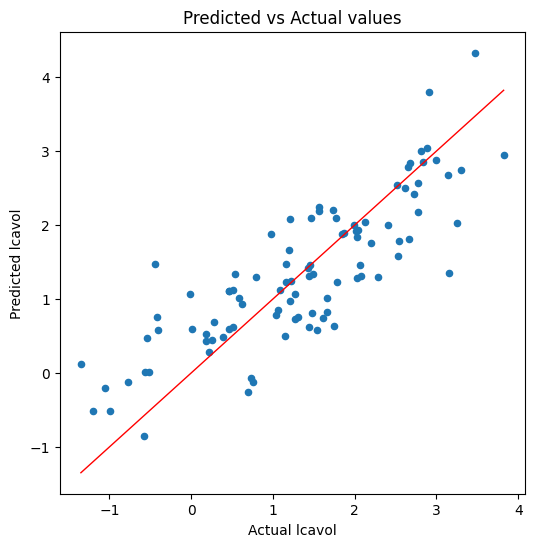

In [7]:
import matplotlib.pyplot as plt

# get predicted values
predictions = results.get_prediction(X)
y_pred = predictions.predicted_mean

# plot predicted vs actual
plt.figure(figsize=(6, 6))
plt.scatter(y, y_pred, s=20)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linewidth=1)
plt.xlabel("Actual lcavol")
plt.ylabel("Predicted lcavol")
plt.title("Predicted vs Actual values")
plt.show()

**(h)** Plot the histogram of residuals as well as their qq-plot using `statsmodels` function `qqplot`. Can we admit that the residuals are normally distributed? Compute the residual sum of squares (RSS).

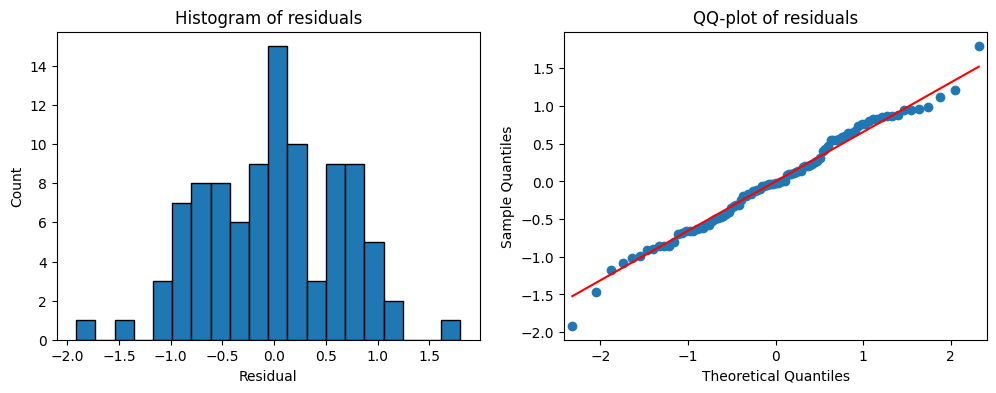

RSS = 41.8141


In [8]:
import statsmodels.api as sm
import matplotlib.pyplot as plt

residuals = results.resid
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(residuals, bins=20, edgecolor='black')
ax[0].set_xlabel("Residual")
ax[0].set_ylabel("Count")
ax[0].set_title("Histogram of residuals")

sm.qqplot(residuals, line='s', ax=ax[1])
ax[1].set_title("QQ-plot of residuals")

plt.show()

RSS = np.sum(residuals**2)
print(f"RSS = {RSS:.4f}")

Yes, reasonably so. Here's the evidence:

Histogram is roughly bell-shaped and centered at zero ✅
QQ-plot points follow the line closely ✅
From part (c), Jarque-Bera p-value was 0.939 (very high → cannot reject normality) ✅
Skewness was -0.073 (essentially zero) ✅

**(i)** What happens if predictors `lpsa` and `lcp` are removed from the multiple linear regression model? Note that you can pass a list of strings to `df.columns.drop` method.

In [32]:

X_reduced = X[X.columns.drop(['lpsa', 'lcp'])]

model_reduced = sm.OLS(y, X_reduced)
results_reduced = model_reduced.fit()
print(results_reduced.summary())
residuals_reduced = results_reduced.resid
RSS_reduced = np.sum(residuals_reduced**2)
print(f"RSS full model    = {41.8141:.4f}")
print(f"RSS reduced model = {RSS_reduced:.4f}")

                            OLS Regression Results                            
Dep. Variable:                 lcavol   R-squared:                       0.433
Model:                            OLS   Adj. R-squared:                  0.381
Method:                 Least Squares   F-statistic:                     8.390
Date:                Mon, 23 Feb 2026   Prob (F-statistic):           2.11e-08
Time:                        01:24:18   Log-Likelihood:                -125.58
No. Observations:                  97   AIC:                             269.2
Df Residuals:                      88   BIC:                             292.3
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
lweight        0.5850      0.259      2.257      0.0

Main conclusion
Removing lpsa and lcp makes the model dramatically worse. This confirms they are the two most important predictors. Interestingly, their removal also changes which other variables appear significant — showing that predictors don't exist in isolation, they interact and share explanatory power with each other.

## ▶️ Exercise 3: Best subset selection (5 points)

A regression model that uses $k$ predictors is said to be of size $k$. For instance, 

$$
\texttt{lcavol} = \beta_1 \texttt{lpsa} + \beta_0 + \varepsilon \quad \text{and} \quad \texttt{lcavol} = \beta_1 \texttt{lweight} + \beta_0 + \varepsilon
$$

are models of size one. The regression model without any predictor $\texttt{lcavol} = \beta_0 + \varepsilon$ is a model of size 0.

The goal of this exercise is to select the best model of size $k$ for each $k \in \{0, \dots, 8\}$.

**(a)** Compute the residual sums of squares (RSS) for all models of size $k = 2$. Which model has the smallest RSS? Note that you can use a generator [`itertools.combination`](https://docs.python.org/3/library/itertools.html#itertools.combinations) to automatize for you all the combinations of $k$ elements among $n$.

**(b)** For each value of $k \in \{0, \dots, 8\}$, select the set of predictors that minimizes the RSS. Plot these values as a function of $k$. Provide the names of the selected predictors for each value of $k$.

**(c)** Do you think that minimizing the residual sum of squares is well suited to select the optimal size for the regression models? Justify your answer using what you've learned in class.

Size 1: RSS=61.4209, predictors=('lpsa',)
Size 2: RSS=47.2781, predictors=('lcp', 'lpsa')
Size 3: RSS=46.2378, predictors=('age', 'lcp', 'lpsa')
Size 4: RSS=44.8784, predictors=('age', 'lbph', 'lcp', 'lpsa')
Size 5: RSS=44.3113, predictors=('age', 'lbph', 'lcp', 'pgg45', 'lpsa')
Size 6: RSS=43.7760, predictors=('age', 'lbph', 'lcp', 'pgg45', 'lpsa', 'gleason_8')
Size 7: RSS=42.4736, predictors=('age', 'lbph', 'lcp', 'pgg45', 'lpsa', 'gleason_7', 'gleason_9')
Size 8: RSS=42.1739, predictors=('age', 'lbph', 'lcp', 'pgg45', 'lpsa', 'gleason_7', 'gleason_8', 'gleason_9')
Size 9: RSS=41.8154, predictors=('age', 'lbph', 'lcp', 'pgg45', 'lpsa', 'svi_1', 'gleason_7', 'gleason_8', 'gleason_9')
Size 10: RSS=41.8141, predictors=('lweight', 'age', 'lbph', 'lcp', 'pgg45', 'lpsa', 'svi_1', 'gleason_7', 'gleason_8', 'gleason_9')


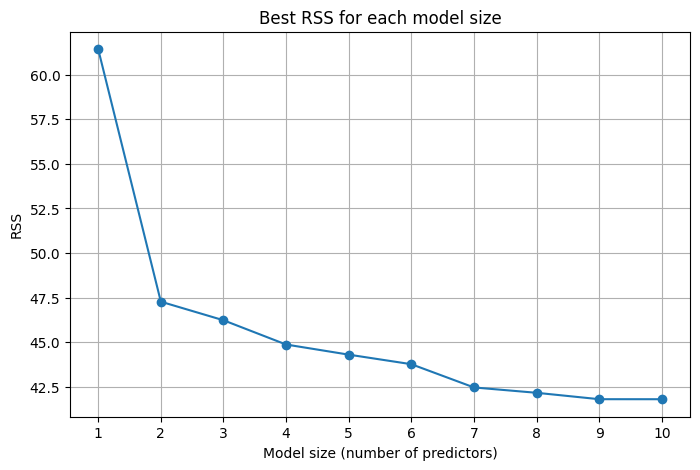


Best predictors for each model size:
Size 1: ['lpsa']
Size 2: ['lcp', 'lpsa']
Size 3: ['age', 'lcp', 'lpsa']
Size 4: ['age', 'lbph', 'lcp', 'lpsa']
Size 5: ['age', 'lbph', 'lcp', 'pgg45', 'lpsa']
Size 6: ['age', 'lbph', 'lcp', 'pgg45', 'lpsa', 'gleason_8']
Size 7: ['age', 'lbph', 'lcp', 'pgg45', 'lpsa', 'gleason_7', 'gleason_9']
Size 8: ['age', 'lbph', 'lcp', 'pgg45', 'lpsa', 'gleason_7', 'gleason_8', 'gleason_9']
Size 9: ['age', 'lbph', 'lcp', 'pgg45', 'lpsa', 'svi_1', 'gleason_7', 'gleason_8', 'gleason_9']
Size 10: ['lweight', 'age', 'lbph', 'lcp', 'pgg45', 'lpsa', 'svi_1', 'gleason_7', 'gleason_8', 'gleason_9']


In [9]:
import itertools

predictors = X.columns.drop('intercept').tolist()
n_predictors = len(predictors)

all_results = {}

for size in range(1, n_predictors + 1):
    best_rss = np.inf
    best_combo = None
   
    for combo in itertools.combinations(predictors, size):
        cols = list(combo) + ['intercept']
        X_sub = X[cols]
        res = sm.OLS(y, X_sub).fit()
        rss = np.sum(res.resid**2)
        if rss < best_rss:
            best_rss = rss
            best_combo = combo
    
    all_results[size] = {'predictors': best_combo, 'rss': best_rss}
    print(f"Size {size}: RSS={best_rss:.4f}, predictors={best_combo}")

sizes = list(all_results.keys())
rss_values = [all_results[s]['rss'] for s in sizes]
plt.figure(figsize=(8, 5))
plt.plot(sizes, rss_values, marker='o')
plt.xlabel("Model size (number of predictors)")
plt.ylabel("RSS")
plt.title("Best RSS for each model size")
plt.xticks(sizes)
plt.grid(True)
plt.show()

print("\nBest predictors for each model size:")
for size in sizes:
    print(f"Size {size}: {list(all_results[size]['predictors'])}")




minimizing RSS always favors the biggest model because adding more predictors always reduces RSS, even if those predictors are useless, so no it is not always the way to select optimal size.

## ▶️ Exercise 4: Split-validation (5 points)

You have now found the best model for each of the nine possible model sizes. In the following, we wish to compare these nine diﬀerent regression models.

**(a)** Give a brief overview of split-validation: how it works? Why it is not subject to the same issues raised in
the item (c) of the previous Exercise?

**(b)** Use function `train_test_split` from the `sklearn` package to split the dataset into a training and a validation (or test) partition. You can set `test_size=0.3`. For each of the nine models from before (i.e. those that minimized the RSS for each size $k$), compute the mean prediction error calculated over the samples from the test set and compare it to its corresponding mean training error. Plot a curve for each of these error as a function of size $k$. 

**(c)** Based on the previous results, choose the best model for this dataset, giving the parameter estimates for the model trained on the whole dataset (i.e. without splitting), and explain your choice.

**(d)** What is the main limitation of split-validation ? Illustrate this issue on the cancer dataset. What could
you do to address this problem? Code such alternative method and comment the result. Note that `sklearn` can provide you with many choices. See [here](https://scikit-learn.org/stable/model_selection.html) for more information.

Split validation works by dividing your data into 2 parts: a training set (70%) and a testing set (30%), it gives an honest measure of how well the model predicts new unseen data, which prevents the RSS overfitting problem.

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

train_errors = []
test_errors = []

for size in range(1, n_predictors + 1):
    best_combo = list(all_results[size]['predictors']) + ['intercept']
    res = sm.OLS(y_train, X_train[best_combo]).fit()
    train_pred = res.predict(X_train[best_combo])
    train_mse = np.mean((y_train.values - train_pred.values)**2)
    train_errors.append(train_mse)
    test_pred = res.predict(X_test[best_combo])
    test_mse = np.mean((y_test.values - test_pred.values)**2)
    test_errors.append(test_mse)
plt.figure(figsize=(8, 5))
plt.plot(range(1, n_predictors + 1), train_errors, marker='o', label='Training error')
plt.plot(range(1, n_predictors + 1), test_errors, marker='o', label='Test error')
plt.xlabel("Model size k")
plt.ylabel("Mean prediction error")
plt.title("Training vs Test error by model size")
plt.legend()
plt.xticks(range(1, n_predictors + 1))
plt.grid(True)
plt.show()

best_size = test_errors.index(min(test_errors)) + 1
print(f"Best model size: {best_size}")
print(f"Best predictors: {list(all_results[best_size]['predictors'])}")

best_combo = list(all_results[best_size]['predictors']) + ['intercept']
final_model = sm.OLS(y, X[best_combo]).fit()
print(final_model.summary())

ModuleNotFoundError: No module named 'sklearn'

## ▶️ Exercise 5: Conclusion (2 points)

What is your conclusion about the choice of the best model to predict `lcavol` ? Comment your results.

This TP consistently shows that a small model using lpsa and lcp as predictors is the best choice. However, this may not be accurate because of the small size of the dataset (97 patients only), so a bigger dataset would allow us to make safer conclusions and choose a model more accurately.